<a href="https://colab.research.google.com/github/cedizen/datahouse/blob/main/house_market.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Projet housemarket**

Dans ce projet, je m'appuie sur une base de données immobilière fictive pour explorer les facteurs associés au prix de vente des maisons à l'aide de tests statistiques. L'objectif principal est d'utiliser différentes méthodes d'inférence (comparaison de moyennes, analyses de groupes, tests d'hypothèses) afin d'identifier quelles caractéristiques des biens (surface, condition, présence de waterfront, rénovation, etc.) sont liées à des variations significatives de prix.

Après une phase de préparation des données, j'étudie la distribution des variables clés et je construis plusieurs sous-ensembles pertinents (par exemple maisons avec vs sans waterfront, biens rénovés vs non rénovés). J'applique ensuite des tests statistiques pour comparer les prix moyens entre ces groupes et évaluer la significativité des différences observées, en gardant comme fil conducteur une interprétation orientée "business" du marché immobilier simulé.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_house = pd.read_csv("data.csv")

In [3]:
df_house.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [4]:
df_house.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

L'analyse globale de la base de données montre un nombre similaire d'observations et aucune valeur nulle. Tous les types sont aussi bien respectés sauf peut-être la date.

In [5]:
df_house["date"].value_counts()

,count
date,
2014-06-23 00:00:00,142
2014-06-25 00:00:00,131
2014-06-26 00:00:00,131
2014-07-08 00:00:00,127
2014-07-09 00:00:00,121
...,...
2014-06-07 00:00:00,4
2014-07-06 00:00:00,3
2014-05-11 00:00:00,2


In [6]:
df_house["date_cleaned"] = pd.to_datetime(df_house["date"])

Donc ici la date est remplacé par un nouveau champs au bon format pour une meilleure manipulation future.

In [7]:
df_house.nunique()

,0
date,70
price,1741
bedrooms,10
bathrooms,26
sqft_living,566
sqft_lot,3113
floors,6
waterfront,2
view,5
condition,5


# **Tests statistiques**

## **Comparaison du prix moyen entre les maisons avec et sans vue**

**Contexte / question métier**

Les maisons avec vue (view > 0) ont-elle un prix moyen significativement différent des maisons sans vue (view = 0)?

**Définition des groupes et de la variable**

- Variable expliquée: price (prix de vente)
- Groupes comparés: groupe 1 -> view = 0 et groupe 2 -> view > 0

**Formulation des hypothèses**

- H0 -> Le prix moyen est identique entre les maisons sans vue et celles avec vue
- H1 -> Le prix moyen est différent entre les maisons avec et sans vue

**Choix du test et hypothèses du test**

- Type de test utilisé: t-test ou Mann-Whitney pour échantillons indépendants selon si les données sont normalisées ou non

In [8]:
n_no_views_price = df_house.loc[df_house["view"] == 0, "price"]
n_views_price = df_house.loc[df_house["view"] > 0, "price"]

In [9]:
n_no_views_price_metrics = n_no_views_price.describe()
n_views_price_metrics = n_views_price.describe()

In [10]:
n_view_price_metrics = pd.concat([n_no_views_price_metrics, n_views_price_metrics], axis=1)

In [11]:
n_view_price_metrics

,price,price
count,4.140000e+03,4.600000e+02
mean,5.106849e+05,9.234657e+05
std,5.343501e+05,6.759432e+05
min,0.000000e+00,0.000000e+00
25%,3.120000e+05,5.065000e+05
50%,4.409125e+05,7.500000e+05
75%,6.150000e+05,1.151850e+06
max,2.659000e+07,7.062500e+06


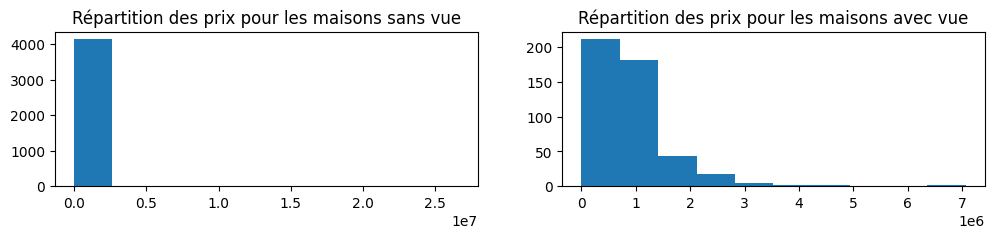

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 2))
ax[0].hist(n_no_views_price)
ax[0].set_title("Répartition des prix pour les maisons sans vue")
ax[1].hist(n_views_price)
ax[1].set_title("Répartition des prix pour les maisons avec vue")
plt.show()

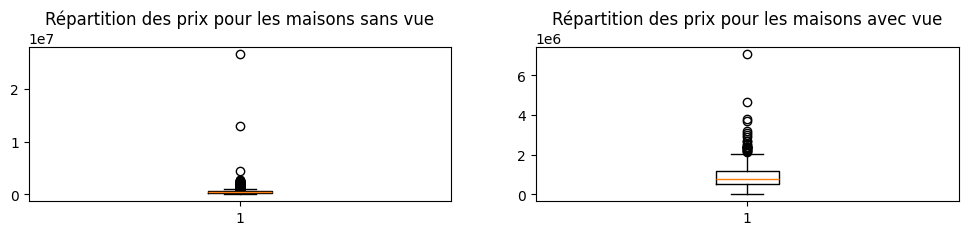

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12, 2))
ax[0].boxplot(n_no_views_price)
ax[0].set_title("Répartition des prix pour les maisons sans vue")
ax[1].boxplot(n_views_price)
ax[1].set_title("Répartition des prix pour les maisons avec vue")
plt.show()

Basée sur les observations précédentes:
- les maisons sans vue ont **une moyenne d'environ 511000** et **une médiane d'environ 441000** pour 460 observations
- Les maisons avec vue ont **une moyenne d'environ 923000** et **une médiane d'environ 750000** pour 4140 observations donc plus de 80% des observations

Une différence plus importante surtout sur le prix pour les maisons avec vue confirmée par la présence de nombreux outliers.
Donc au lieu d'un t-test qui mesure la moyenne et donc sensible aux outliers, mieux vaut partir sur le test de Mann-Whitney plus robuste à des données asymétriques.

In [14]:
from scipy.stats import mannwhitneyu

In [15]:
stats, pvalue = mannwhitneyu(n_no_views_price, n_views_price, alternative="two-sided")

print(f"pvalue {pvalue}")
print(f"stats: {stats}")

seuil = 0.05

if pvalue < seuil:
  print("H0 rejeté. Il existe au moins une différence de prix moyen entre les maisons sans vue et avec vue")
else:
  print("Impossible de rejeter l'hypothèse H0 où il existe une différence entre les maisons avec et sans vue")

pvalue 1.2232655509390107e-72
stats: 465113.0
H0 rejeté. Il existe au moins une différence de prix moyen entre les maisons sans vue et avec vue


Basée sur les observations, la vérification de la distribution des données, nous sommes donc parti sur un test de Mann-Whitney, qui a permis de montrer que il existe une différence suffisamment significative entre les groupes de maison avec un certain niveau de vue et celles qui n'ont pas de vue.

## **Surface moyenne : maison en bord de mer ou non**

**Contexte / question métier**

Est-ce que la surface moyenne d'une maison en bord de mer (waterfront = 1) diffère significativement d'une maison loin du bord de mer (waterfront = 0) ?

**Définition des groupes et de la variable**

- Variable expliquée: surface (sqft_living)
- Groupes comparés: groupe 1 -> waterfront = 0 et groupe 2 -> waterfront = 1
- Groupes sont tous les deux indépendants et non appariés

**Formulation des hypothèses**

- H0 -> La surface moyenne d'une maison en bord de mer et pas en bord de mer est identique
- H1 -> La surface moyenne d'une maison en bord de mer est significativement supérieure à une maison loin du bord de mer

**Choix du test et hypothèses du test**

- Type de test utilisé: t-test ou Mann-Whitney pour échantillons indépendants selon si les données sont normalisées ou non

In [16]:
h0 = "La surface moyenne d'une maison en bord de mer et pas en bord de mer est identique"
H1 = "La surface moyenne d'une maison en bord de mer est plus importante qu'une maison non situé en bord de mer"

In [17]:
n_surface_mer = df_house.loc[df_house["waterfront"] == 1, "sqft_living"]
n_surface_no_mer = df_house.loc[df_house["waterfront"] == 0, "sqft_living"]

In [18]:
n_surface_mer_metrics = n_surface_mer.describe()
n_surface_no_mer_metrics = n_surface_no_mer.describe()

In [19]:
n_surface_mer_metrics = pd.concat([n_surface_mer_metrics, n_surface_no_mer_metrics], axis=1)
n_surface_mer_metrics

,sqft_living,sqft_living
count,33.000000,4567.000000
mean,3471.939394,2129.717977
std,2088.508693,943.915469
min,830.000000,370.000000
25%,2040.000000,1460.000000
50%,2890.000000,1970.000000
75%,4420.000000,2610.000000
max,10040.000000,13540.000000


Basée sur les observations ci-dessus, nous avons:
- 33 observations pour les maisons en bord de mer avec un moyenne de 3471 et une médiane de 2890
- 4567 observations pour les maisons loin du bord de mer avec une moyenne de de 2129 et une médiane à 1970.

On peut constater la présence d'outliers puisque la médiane est moins élevé que la moyenne.
Toutefois, cela ne suffit pas à définir si un test non-paramétrique ou paramétrique est nécessaire. C'est ce que nous allons voir avec la distribution des données via des boxplot ou des histogrammes

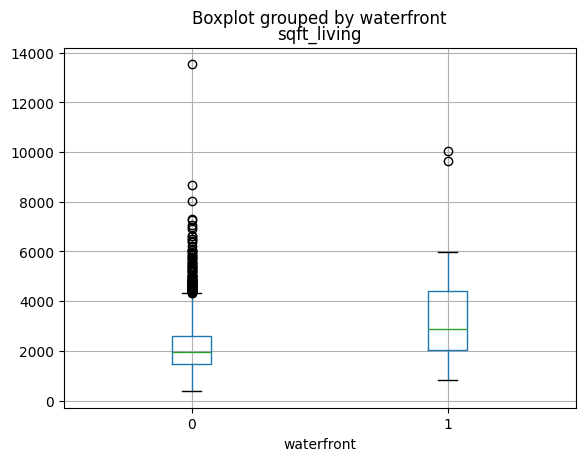

In [20]:
df_house.boxplot(by="waterfront", column="sqft_living")
plt.show()

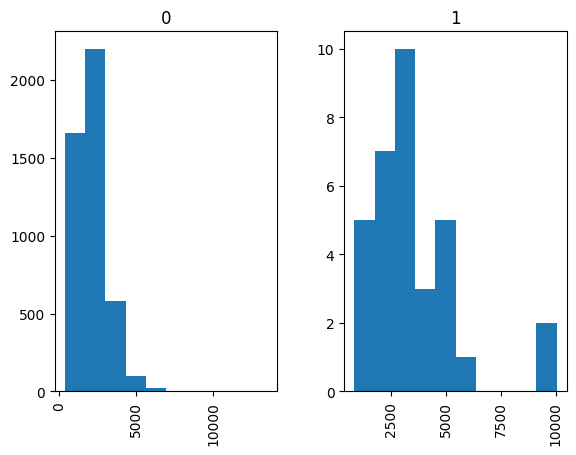

In [54]:
df_house.hist(by="waterfront", column="sqft_living")
plt.show()

On peut remarquer une asymétrie marqué que ce soit pour les maisons en bord de mer ou celles loin du bord de mer. Donc il est nécessaire d'utiliser un test non-paramétrique.

In [23]:
stats_ww, pvalue_ww = mannwhitneyu(n_surface_mer, n_surface_no_mer, alternative="greater")

print(f"pvalue {pvalue_ww}")
print(f"stats: {stats_ww}")

if pvalue_ww < seuil:
  print("H0 rejeté. la surface moyenne est supérieure pour les maisons en bord de mer")
else:
  print("Impossible de rejeter l'hypothèse H0. pas de différence observé en termes de surface entre les maisons en bord de mer et celles qui ne le sont pas")

pvalue 1.196128475224356e-06
stats: 111213.5
H0 rejeté. la surface moyenne est supérieure pour les maisons en bord de mer


Ok maintenant regardons les résultats visuels

In [55]:
df_house.groupby("waterfront").agg(sqft_living_median=("sqft_living", "median"))\
.plot(kind="bar")

,sqft_living_median
waterfront,
0,1970.0
1,2890.0


En conclusion, grâce au test de Mann-Whitney et à la visualisation des résultats, l'hypothèse nulle n'est pas retenu car le resultat statistique (pvalue) est inférieur au seuil minimum de 5%. L'hypothèse H1 est donc retenu supporté par le résultat visuel.

Par conséquent, les maisons en bord de mer ont bien une surface médiane significativement plus important que celles loin du bord de mer (+900 de différence).

## **Prix moyen par nombre de chambres**

**Contexte / question métier**

Est-ce que la surface moyenne d'une maison en bord de mer (waterfront = 1) diffère significativement d'une maison loin du bord de mer (waterfront = 0) ?

**Définition des groupes et de la variable**

- Variable expliquée: prix (price)
- Groupes comparés: 10 groupes de 0 chambres (studio) à une maison à 9 chambres
- Tous les groupes sont indépendants

**Formulation des hypothèses**

Maintenant formulons les hypothèses:
- H0 -> Aucun groupe de chambres n'observe une variation du prix moyen
- H1 -> Au moins un groupe a un prix moyen qui varie

**Choix du test et hypothèses du test**

- Type de tests envisagés: ANOVA pour comparer la moyenne de chaque groupe si les données sont normalement distribuées et Kruskal si présence de valeurs outliers et d'une distribution très asymétrique.

In [25]:
h0_price_bedrooms = "Pas de variation de prix entre les différents groupes de chambre"
h1_price_bedrooms = "Au moins un groupe de chambres a un prix qui varie"

In [26]:
df_house["bedrooms"].value_counts()

,count
bedrooms,
3.0,2032
4.0,1531
2.0,566
5.0,353
6.0,61
1.0,38
7.0,14
8.0,2
0.0,2


Ici nous avons 10 niveau d'une maison avec 0 chambres (type studio) à une maison avec 9 chambres.

La variable prix est la valeur qui nous permet de comparer les différents groupes.

Avec plusieurs groupes et une variable quantitative, le choix se porte sur Kruskal ou ANOVA.

Etape 1: regarder la distribution

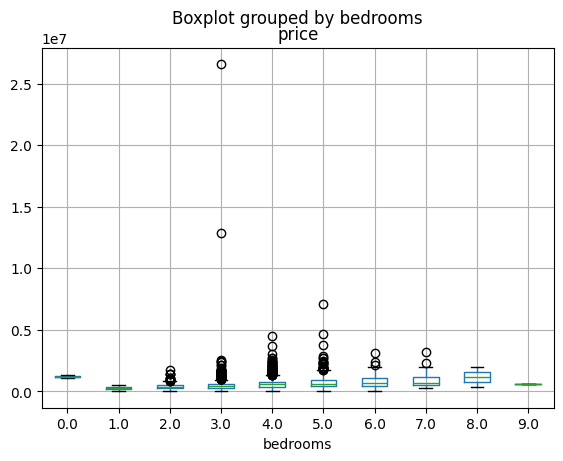

In [56]:
df_house.boxplot(by="bedrooms", column="price")
plt.show()

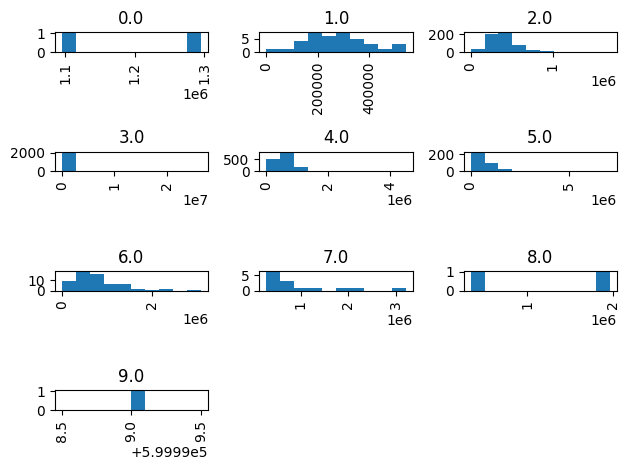

In [28]:
df_house.hist(by="bedrooms", column="price")
plt.tight_layout()
plt.show()

Donc une moyenne qui est presque d'un point au dessus de la médiane. La moyenne est donc influencée par les outliers. Un test ANOVA n'est donc pas approprié ici en raison d'une utilisation biaisée de la moyenne.

Nous allons donc utiliser un test non-paramétrique qui prend en compte des données non normalisées: kruskal.

In [30]:
from scipy.stats import kruskal

groups_price_bedrooms = [group["price"].values for name, group in df_house.groupby("bedrooms")]

In [31]:
stats_price_bedrooms, pvalue_price_bedrooms = kruskal(*groups_price_bedrooms)

print(f"Stats entre le prix de la surface et le nombre de chambres : {stats_price_bedrooms}")
print(f"Pvalue entre le prix de la surface et le nombre de chambres : {pvalue_price_bedrooms}")

Stats entre le prix de la surface et le nombre de chambres : 550.1475562176643
Pvalue entre le prix de la surface et le nombre de chambres : 1.0350107792364518e-112


In [32]:
if pvalue_price_bedrooms < seuil:
  print(f"H0 rejeté. {h1_price_bedrooms}")
else:
  print(f"Impossible de rejeter l'hypothèse H0. {h0_price_bedrooms}")

H0 rejeté. Au moins un groupe de chambres a un prix qui varie


Pas de test post-hoc à réaliser, car test non-paramétrique.

In [33]:
group_bedrooms_price_median = df_house.groupby("bedrooms", as_index=False).agg(prix_median=("price", "median"))

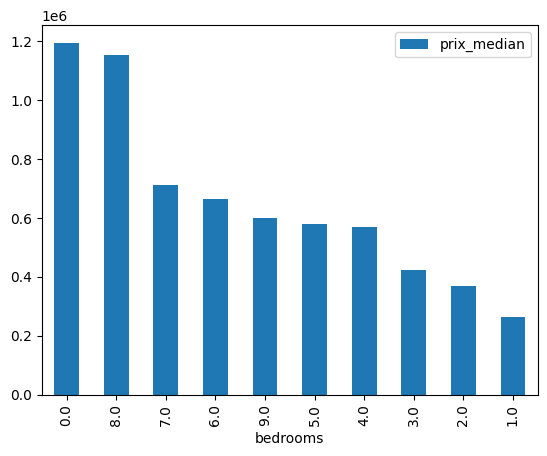

In [34]:
group_bedrooms_price_median.sort_values("prix_median", ascending=False)\
.plot(kind="bar", x="bedrooms", y="prix_median")

plt.show()

Le graphique ci-dessus permet d'illustrer que le prix médian varie significativement entre les différentes maison selon le nombre de chambres.
Il semble que le studio soit le bien qui se valorise le plus suivi par la maison de 8 chambres.

## **Surface habitable par condition**

Dans cette partie, nous étudions si la surface habitable diffère en fonction de sa condition.

Les paramètres à prendre en compte:
- Plusieurs groupes indépendants car différentes conditions
- une variable quantitative: surface du bien

Formulation des hypothèses:
- H0: Aucune variation de surface moyenne au sein des différents groupes
- H1: Au moins une variation de surface moyenne au sein des différents groupes

Dans les étapes suivantes, nous verrons si les données sont normalement distribuées ou asymétriques.
Du résultat dépendra le type de test à réaliser. Si les variables sont normalement distribuées alors test d'ANOVA sinon Kruskal

In [35]:
h0_surface_condition = "Aucune variation de surface moyenne au sein des différents groupes"
h1_surface_condition = "Au moins une variation de surface moyenne au sein des différents groupes"

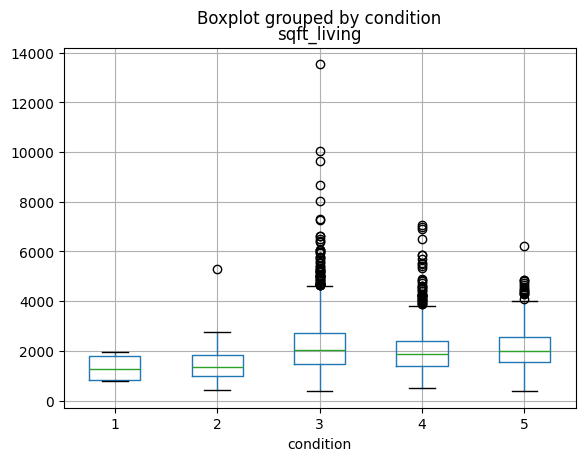

In [36]:
df_house.boxplot(by="condition", column="sqft_living")
plt.show()

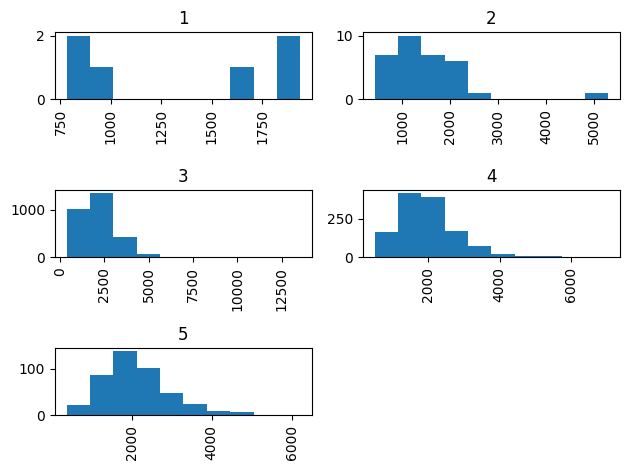

In [37]:
df_house.hist(by="condition", column="sqft_living")
plt.tight_layout()
plt.show()

Certaines conditions sont normalement distribuées tandis que d'autres sont très asymétriques. Afin d'éviter de créer un résultat biaisé, mieux vaut parier sur un test anova alternatif dit pingouin.welch_anova()

In [38]:
from scipy.stats import f_oneway

In [39]:
groups_condition_sqft_living = [group["sqft_living"] for name, group in df_house.groupby("condition")]

In [40]:
stats_condition_sqft_living, pvalue_condition_sqft_living = f_oneway(*groups_condition_sqft_living, equal_var=False)

print(f"Stats: {stats_condition_sqft_living}")
print(f"pvalue: {pvalue_condition_sqft_living}")

if pvalue_condition_sqft_living < seuil:
  print(f"H0 rejeté. {h1_surface_condition}")
else:
  print(f"Echec rejet de l'hypothèse h0. {h0_surface_condition}")

Stats: 20.17782031304757
pvalue: 1.236351107086804e-08
H0 rejeté. Au moins une variation de surface moyenne au sein des différents groupes


In [58]:
group_condition_sqft_median = df_house.groupby("condition", as_index=False).agg(prix_median=("sqft_living", "median"))

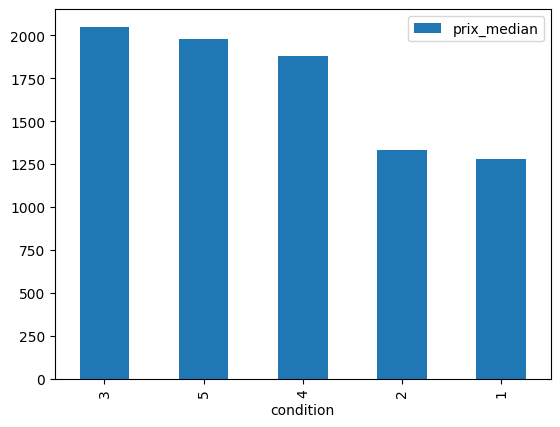

In [63]:
group_condition_sqft_median.sort_values("prix_median", ascending=False)\
.plot(kind="bar", x="condition", y="prix_median")
plt.show()

Basée sur les résultats du test statistique et les résultats visuels, l'hypothèse nulle est rejeté, et montre qu'il existe au moins une différence significative en terme de surface médiane entre les groupes.

Pour pousser d'avantage l'analyse et définir la crédibilité de ces différences inter groupes, nous allons procéder à un test post-hoc: pairwise_gameshowell.

In [41]:
!pip install pingouin

In [42]:
import pingouin as pg

In [43]:
posthoc_sqft_living_condition = pg.pairwise_gameshowell(data=df_house, dv='sqft_living', between='condition')

posthoc_sqft_living_condition

,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges
0,1,2,1325.000000,1526.875000,-201.875000,273.743723,-0.737460,10.552365,9.428002e-01,-0.234330
1,1,3,1325.000000,2218.987478,-893.987478,225.852688,-3.958277,5.070882,5.146820e-02,-0.881786
2,1,4,1325.000000,1986.699681,-661.699681,226.330121,-2.923604,5.113894,1.440920e-01,-0.781218
3,1,5,1325.000000,2108.618391,-783.618391,228.825610,-3.424522,5.343125,8.187923e-02,-0.910229
4,2,3,1526.875000,2218.987478,-692.112478,156.976843,-4.409010,31.920086,9.790529e-04,-0.683142
5,2,4,1526.875000,1986.699681,-459.824681,157.662983,-2.916504,32.481469,4.671801e-02,-0.541726
6,2,5,1526.875000,2108.618391,-581.743391,161.224850,-3.608274,35.505606,7.852688e-03,-0.672514
7,3,4,2218.987478,1986.699681,232.287798,30.519292,7.611179,2820.473740,8.021361e-13,0.240252
8,3,5,2218.987478,2108.618391,110.369087,45.467165,2.427446,630.497788,1.093578e-01,0.110833
9,4,5,1986.699681,2108.618391,-121.918710,47.782318,-2.551544,745.041937,8.069637e-02,-0.143146


On remarque via le tableau ci-dessous de nombreuses différences au niveau statistique mais aussi en termes de pval. Toutes les différences observés sont suffisamment crédibles pour ne pas être liés au hasard.
Si l'on regarde en détail, on peut voir notamment que certaines surfaces en condtion 3, 4 et 5 sont les plus larges quand celles en condition 1 et 2 sont les plus faibles.

## **Corrélations entre le prix et les autres variables quantitatives**

In [44]:
numeric_values = df_house.select_dtypes(include=['float64', 'int64'])

correlations = numeric_values.corr()

corr_prix = correlations[["price"]]

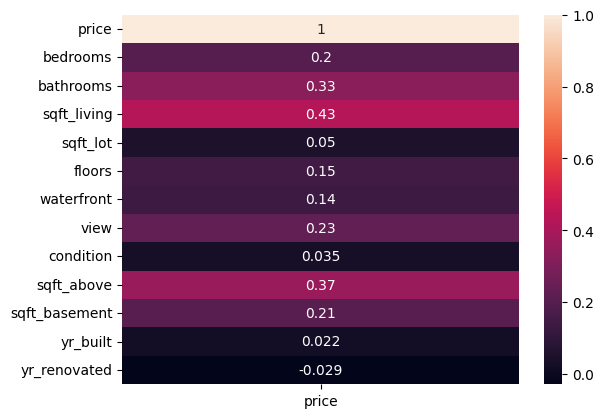

In [45]:
sns.heatmap(
    corr_prix,
    annot=True
)
plt.show()

Les éléments qui ont le plus d'influence sur le prix sont principalement liés à la surface de l'habitation

Regardons les corrélations les plus importantes

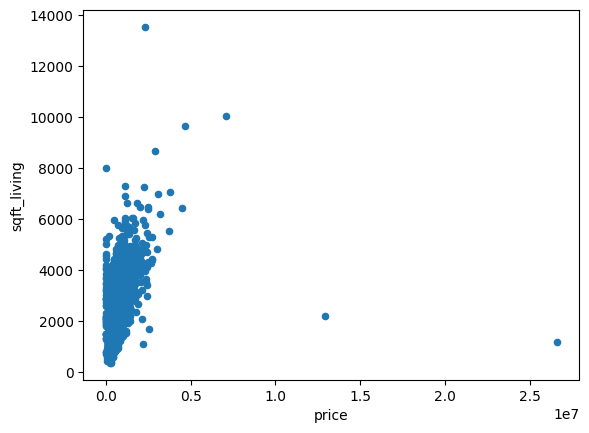

In [46]:
df_house.plot(kind="scatter", x="price", y="sqft_living")
plt.show()

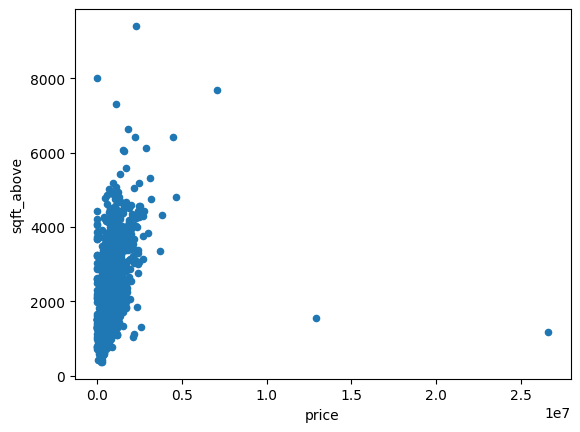

In [47]:
df_house.plot(kind="scatter", x="price", y="sqft_above")
plt.show()

Selon les observations, on peut voir que les éléments n'ont pas un pattern très défini. Cela signifie que la surface n'influence pas forcément une augmentation du prix. Il doit y avoir une combinaison d'autres facteurs.

Nous pouvons quand même tester sur la plus grande corrélation un test de spearmann ou Pearson en fonction de la distribution des données

Formulation des hypothèses pour évaluer la corrélation entre la surface habitable et le prix:
- H0: Le prix n'a pas d'influence sur la surface habitable
- H1: Le prix a une influence sur la surface habitable

In [48]:
h0_surface_prix = "Le prix et la surface habitable n'ont pas d'influence mutuelle"
h1_surface_prix = "Le prix et la surface habitable ont une influence mutuelle"

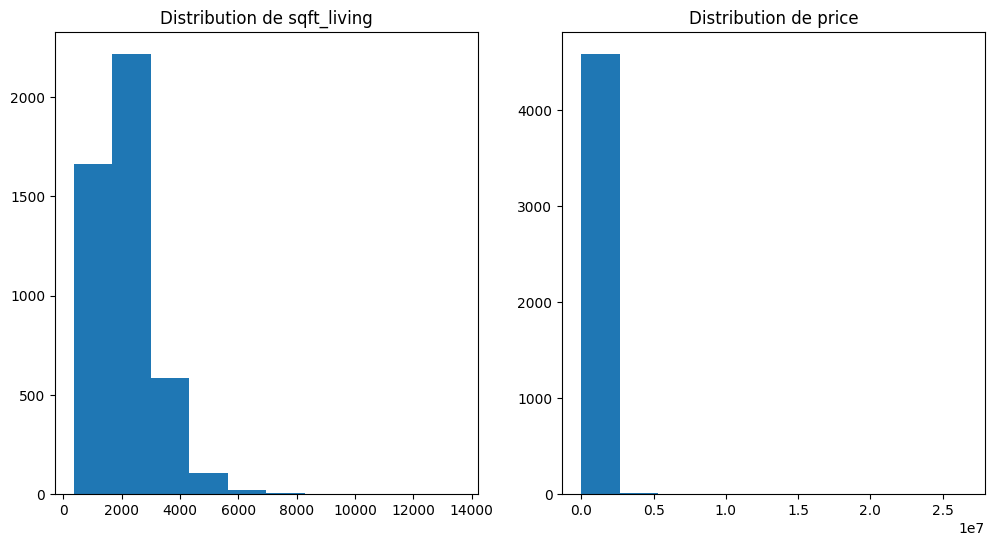

In [68]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].hist(df_house["sqft_living"])
ax[0].set_title("Distribution de sqft_living")
ax[1].hist(df_house["price"])
ax[1].set_title("Distribution de price")
plt.show()

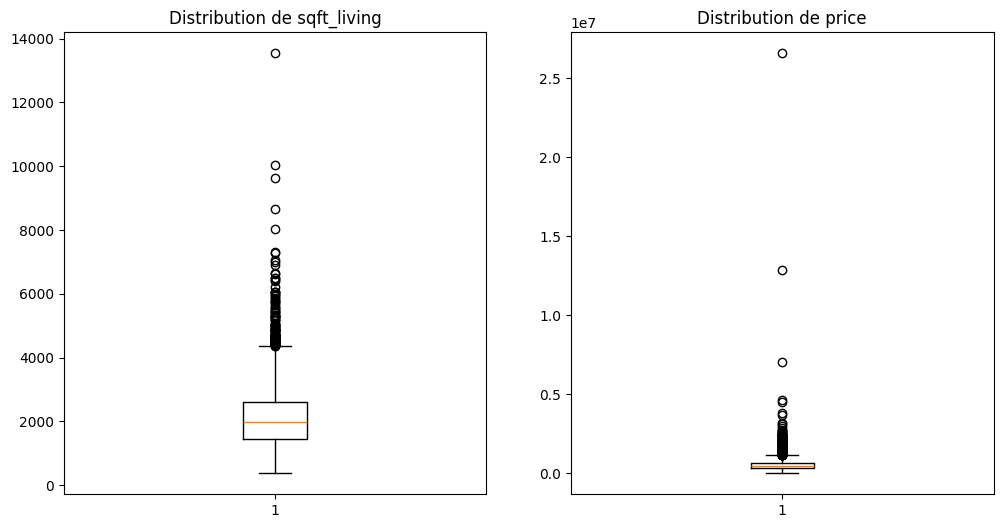

In [69]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].boxplot(df_house["sqft_living"])
ax[0].set_title("Distribution de sqft_living")
ax[1].boxplot(df_house["price"])
ax[1].set_title("Distribution de price")
plt.show()

Données qui semblent très asymétriques, donc présence de nombreux outliers. Voyons maintenant différentes métriques en incluant la médiane et la moyenne.

In [73]:
sqft = df_house["sqft_living"]
price = df_house["price"]

In [74]:
sqft_metric = sqft.describe()
price_metric = price.describe()

In [76]:
sqft_price_metric = pd.concat([sqft_metric, price_metric], axis=1)
sqft_price_metric

,sqft_living,price
count,4600.000000,4.600000e+03
mean,2139.346957,5.519630e+05
std,963.206916,5.638347e+05
min,370.000000,0.000000e+00
25%,1460.000000,3.228750e+05
50%,1980.000000,4.609435e+05
75%,2620.000000,6.549625e+05
max,13540.000000,2.659000e+07


In [84]:
mean_mediane_ratio_sqft = (sqft_price_metric.loc["mean", "sqft_living"] - sqft_price_metric.loc["50%", "sqft_living"])/sqft_price_metric.loc["50%", "sqft_living"]
mean_mediane_ratio_sqft

np.float64(0.08047826086956526)

In [85]:
mean_mediane_ratio_price = (sqft_price_metric.loc["mean", "price"] - sqft_price_metric.loc["50%", "price"])/sqft_price_metric.loc["50%", "price"]
mean_mediane_ratio_price

np.float64(0.19746353843683215)

Selon des données métriques:
- sqft_living a une moyenne de 2139 avec une médiane à 1980 soit une difference d'environ 1800
- price a une moyenne de 551963 et une médiane à 460943 soit une différence de près de 100000

Une telle différence montre que les valeurs dites "outliers" influencent fortement le résultat. Les métriques permettent de confirmer que les données ne sont pas sont normalement distribuées et nécessitent un test robuste à une distribution de type asymétrique.

In [51]:
from scipy.stats import spearmanr

In [52]:
rho_prix_sqft_living, pvalue_prix_sqft_living = spearmanr(df_house["sqft_living"], df_house["price"])

print(f"pvalue: {pvalue_prix_sqft_living}")

if pvalue_prix_sqft_living < seuil:
  print(f"Rejet de l'hypothèse nulle. {h1_surface_prix}")
else:
  print(f"Echec du rejet de l'hypothèse nulle. {h0_surface_prix}")

pvalue: 0.0
Rejet de l'hypothèse nulle. Le prix et la surface habitable ont une influence mutuelle


In [53]:
from scipy.stats import pearsonr

rho_prix_sqft_living, pvalue_prix_sqft_living = pearsonr(df_house["sqft_living"], df_house["price"])

print(f"pvalue: {pvalue_prix_sqft_living}")

if pvalue_prix_sqft_living < seuil:
  print(f"Rejet de l'hypothèse nulle. {h1_surface_prix}")
else:
  print(f"Echec du rejet de l'hypothèse nulle. {h0_surface_prix}")

pvalue: 7.549895925377823e-207
Rejet de l'hypothèse nulle. Le prix et la surface habitable ont une influence mutuelle


Selon les observation graphiques et issues des tests statistiques, la surface habitable et le prix s'influencent mutuellement. Le graphique montre un pattern pas si visible avec une corrélation autour de 0.43.

# **Conclusion générale**

Les tests statistiques réalisés mettent en évidence que certaines caractéristiques des biens immobiliers sont associées à des différences marquées de prix dans ce jeu de données fictif. On observe notamment des écarts de prix moyen entre les biens situés en bord de l'eau et les autres, ainsi qu'entre les biens rénovés et non rénovés, ce qui suggère que ces facteurs jouent un rôle important dans la valorisation d'un logement.

Ces résultats montrent l'intérêt des tests d'hypothèses pour passer d'une simple observation de moyennes à une conclusion plus rigoureuse sur la significativité des écarts de prix entre groupes. ce notebook constitue ainsi une base solide d'entrainement à l'utilisation des tests statistiques en contexte immobilier et pourrait être prolongé par d'autres analyses (tests supplémentaires, ajustement pour plusieurs facteurs à la fois, ou ajout ultérieur d'un modèle de régression) si l'on souhaite aller vers une modélisation plus complète.